# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1, 2026-2027 — Major Project**

**Author:JAYDEEP POPAT


---

## 1. Introduction

Agricultural performance is influenced by seasonal variations in weather, soil conditions, resource
availability and market factors. This project analyzes a farm-level dataset covering three Indian
cropping seasons — **Kharif, Rabi and Zaid** — to understand how agricultural performance differs
across seasons and to uncover patterns, relationships and anomalies that can support evidence-based
agricultural planning.

## 2. Problem Statement

Raw agricultural data does not, on its own, explain how performance changes from season to season.
This notebook investigates seasonal differences in yield, cost, revenue, profit, resource usage and
environmental conditions, and draws data-driven conclusions and recommendations.

## 3. Objectives

- Explore and understand the dataset structure and quality.
- Clean and prepare the data (missing values, duplicates, outliers).
- Examine how agricultural performance varies across seasons.
- Identify seasonal patterns and relationships between environmental conditions and outcomes.
- Compare crops, states and irrigation methods across seasons.
- Apply statistical tests and visualizations to validate findings.
- Draw evidence-based conclusions and recommendations.


In [1]:
# 4. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 5. Load the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 6. Data Cleaning and Preparation

Before analysis, we check for missing values, duplicate records and outliers, since these can distort
seasonal comparisons if left untreated.

In [5]:
# 6.1 Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print("\nPercentage of missing values:")
print((missing / len(df) * 100).round(2))


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percentage of missing values:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [6]:
# 6.2 Duplicate records
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())


Number of duplicate rows: 0
Number of duplicate Farm_IDs: 0


In [7]:
# 6.3 Handle missing values
# Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha have a small number of missing values.
# We impute them using the median WITHIN each season, since these variables are strongly
# season-dependent (imputing with a global median would distort seasonal comparisons).

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values after imputation:")
print(df.isnull().sum().sum())


Remaining missing values after imputation:
0


In [8]:
# 6.4 Outlier detection using IQR method on key performance columns
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_report = {}
for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_INR', 'Production_Tonnes']:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    outlier_report[col] = {'lower_bound': round(low,2), 'upper_bound': round(high,2), 'outliers': n_out}

pd.DataFrame(outlier_report).T


,lower_bound,upper_bound,outliers
Yield_Tonnes_Ha,-1.62,5.50,302.0
Water_Efficiency_t_per_1000m3,-3.57,10.38,322.0
Profit_INR,-696111.00,763567.00,404.0
Production_Tonnes,-23.98,53.36,333.0


In [9]:
# 6.5 Cap extreme outliers (winsorize) for Yield_Tonnes_Ha and Water_Efficiency_t_per_1000m3
# rather than deleting rows, so we retain sample size while limiting distortion from
# a few implausible values (e.g. yield of 100+ tonnes/hectare is not realistic for these crops).

for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']:
    low, high = iqr_bounds(df[col], k=3)  # wide cap - only trims extreme values
    df[col] = df[col].clip(lower=low, upper=high)

print("Post-treatment max values:")
print(df[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].max())


Post-treatment max values:
Yield_Tonnes_Ha                   8.170
Water_Efficiency_t_per_1000m3    15.618
dtype: float64


In [10]:
# 6.6 Feature engineering - derived metrics useful for seasonal comparison
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_per_Hectare'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
df['Is_Profitable'] = df['Profit_INR'] > 0

df[['Profit_Margin_pct', 'Cost_per_Hectare', 'Revenue_per_Hectare', 'Is_Profitable']].describe(include='all')


,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare,Is_Profitable
count,4000.000000,4000.000000,4000.000000,4000
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,2034
mean,-45.492178,66660.084938,80215.109448,NaN
std,158.085472,8845.644258,58262.570038,NaN
min,-1461.851219,35807.382550,4439.466896,NaN
25%,-60.192762,60597.205943,42325.161826,NaN
50%,1.146236,66614.048166,67082.984401,NaN
75%,32.885876,72739.977527,96800.414327,NaN


## 7. Exploring the Dataset Structure

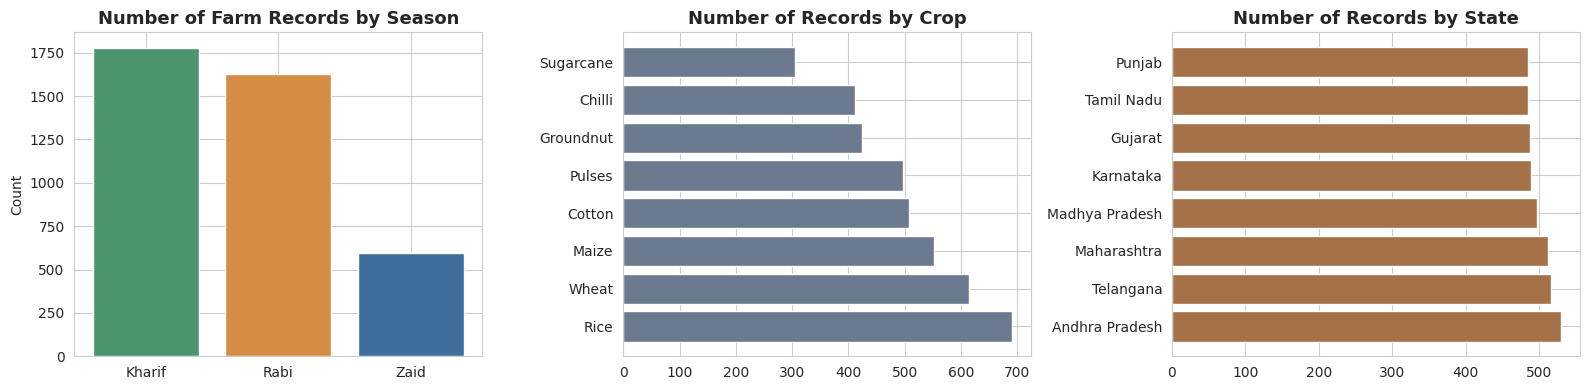

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

season_counts = df['Season'].value_counts()
axes[0].bar(season_counts.index, season_counts.values, color=['#4C956C','#D68C45','#3E6D9C'])
axes[0].set_title('Number of Farm Records by Season')
axes[0].set_ylabel('Count')

crop_counts = df['Crop'].value_counts()
axes[1].barh(crop_counts.index, crop_counts.values, color='#6B7A8F')
axes[1].set_title('Number of Records by Crop')

state_counts = df['State'].value_counts()
axes[2].barh(state_counts.index, state_counts.values, color='#A47148')
axes[2].set_title('Number of Records by State')

plt.tight_layout()
plt.savefig('fig_01_overview.png', dpi=120)
plt.show()


In [12]:
pd.crosstab(df['Season'], df['Crop'])


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


**Observation:** Kharif has the most records (1,779), followed by Rabi (1,627) and Zaid (594),
reflecting that Zaid is a short summer season grown in fewer regions. Crops are not evenly spread
across seasons — this needs to be kept in mind when comparing season-level averages.

## 8. How Do Environmental Conditions Vary Across Seasons?

In [13]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
season_env = df.groupby('Season')[env_cols].mean().round(2)
season_env


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


/tmp/ipykernel_533/4110331900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette=colors,
/tmp/ipykernel_533/4110331900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette=colors,
/tmp/ipykernel_533/4110331900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette=colors,
/tmp/ipykernel_533/4110331900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

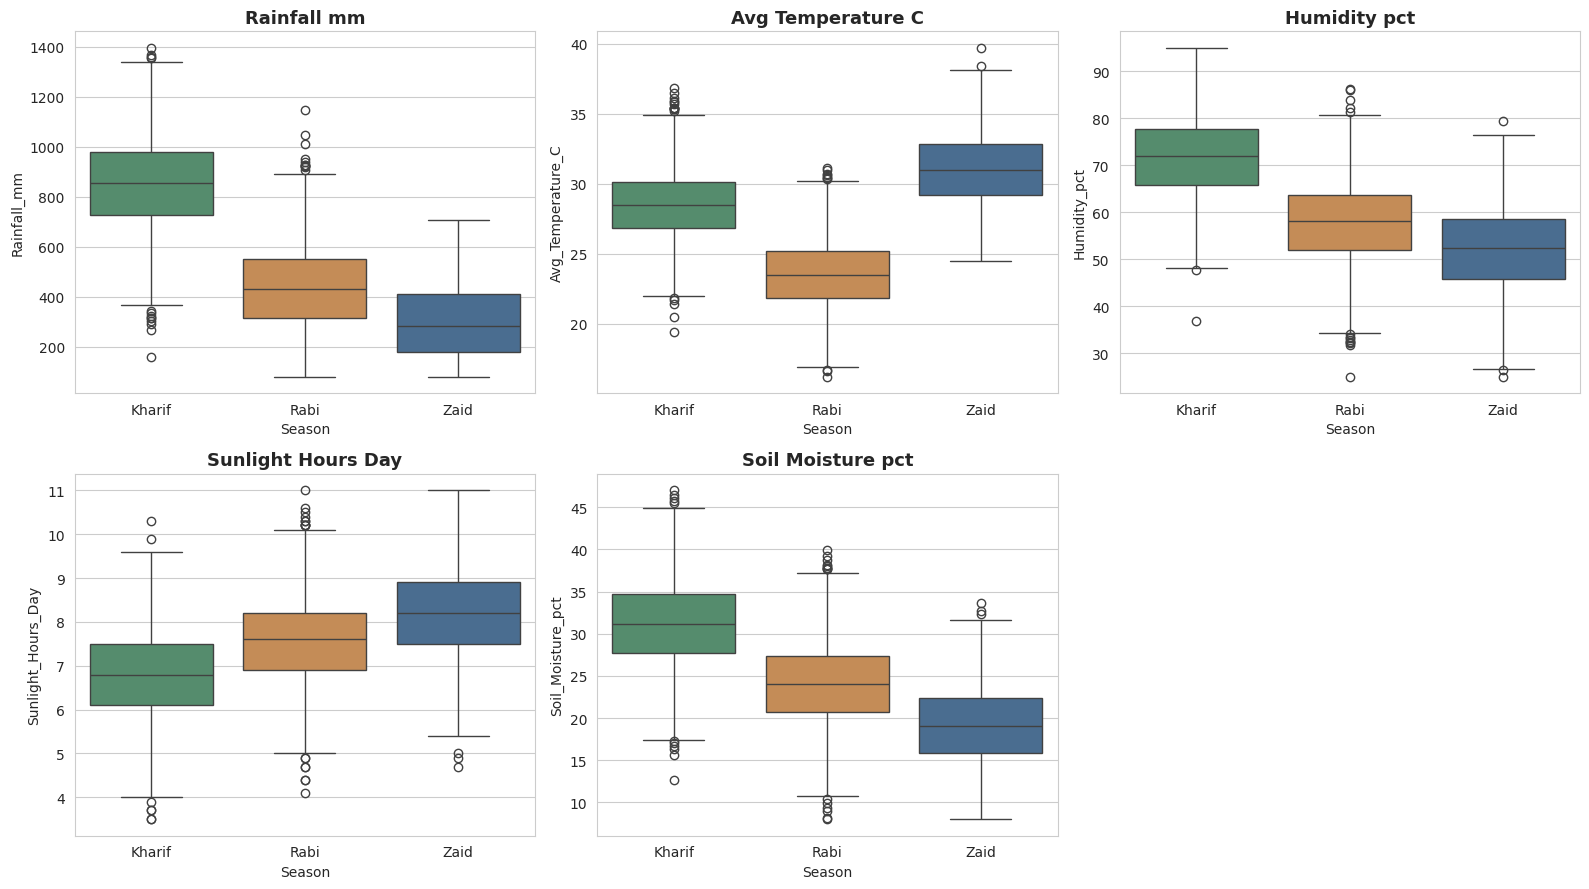

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = {'Kharif':'#4C956C','Rabi':'#D68C45','Zaid':'#3E6D9C'}

for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette=colors,
                order=['Kharif','Rabi','Zaid'])
    axes[i].set_title(col.replace('_',' '))

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('fig_02_environment.png', dpi=120)
plt.show()


**Observation:** Kharif season shows the highest rainfall and humidity (monsoon season), Rabi
shows the lowest temperatures (winter cropping season), and Zaid — the short summer season — shows
the lowest rainfall and soil moisture but comparable sunlight hours. These environmental differences
are consistent with known Indian cropping-season characteristics and validate that the dataset
behaves realistically.

## 9. How Does Agricultural Performance Vary Across Seasons?

In [15]:
perf_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Profit_Margin_pct',
             'Revenue_per_Hectare', 'Cost_per_Hectare']
season_perf = df.groupby('Season')[perf_cols].mean().round(2)
season_perf


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Profit_Margin_pct,Revenue_per_Hectare,Cost_per_Hectare
Season,,,,,,
Kharif,2.43,46.31,178914.65,-38.64,88782.79,66900.98
Rabi,2.23,41.49,87689.47,-44.27,76656.92,66295.24
Zaid,2.03,38.89,-24804.82,-69.35,64301.42,66937.94


/tmp/ipykernel_533/156975146.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette=colors, order=['Kharif','Rabi','Zaid'])
/tmp/ipykernel_533/156975146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[0,1], palette=colors, order=['Kharif','Rabi','Zaid'])
/tmp/ipykernel_533/156975146.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_Margin_pct', ax=axes[1,0], palette=colors,


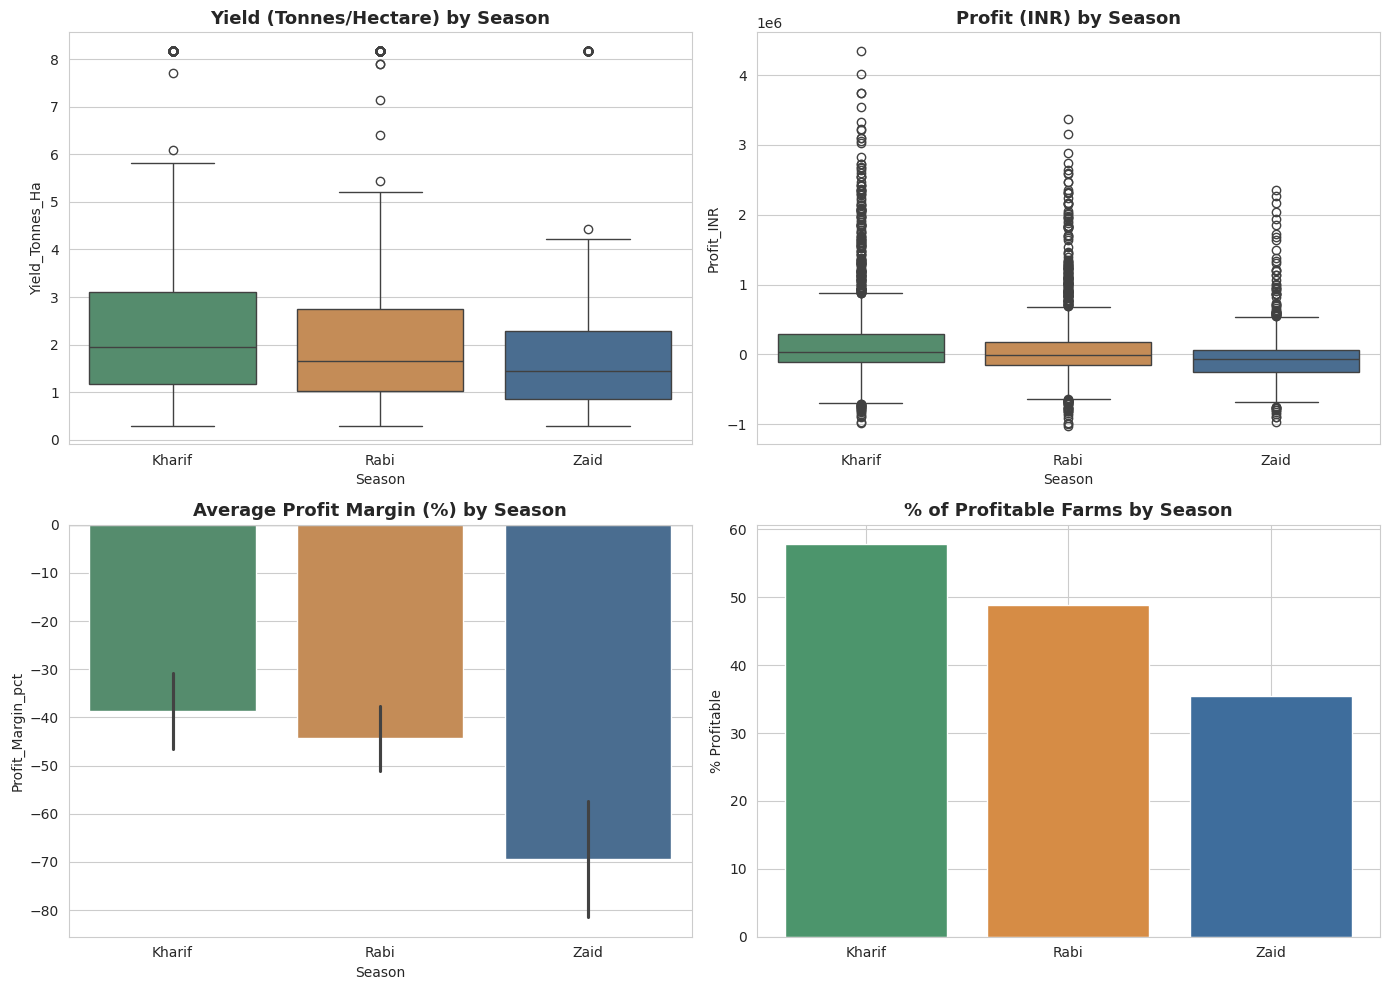

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette=colors, order=['Kharif','Rabi','Zaid'])
axes[0,0].set_title('Yield (Tonnes/Hectare) by Season')

sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[0,1], palette=colors, order=['Kharif','Rabi','Zaid'])
axes[0,1].set_title('Profit (INR) by Season')

sns.barplot(data=df, x='Season', y='Profit_Margin_pct', ax=axes[1,0], palette=colors,
            order=['Kharif','Rabi','Zaid'], estimator=np.mean, errorbar=('ci', 95))
axes[1,0].set_title('Average Profit Margin (%) by Season')
axes[1,0].axhline(0, color='black', linewidth=0.8)

profitable_pct = df.groupby('Season')['Is_Profitable'].mean().reindex(['Kharif','Rabi','Zaid']) * 100
axes[1,1].bar(profitable_pct.index, profitable_pct.values, color=[colors[s] for s in profitable_pct.index])
axes[1,1].set_title('% of Profitable Farms by Season')
axes[1,1].set_ylabel('% Profitable')

plt.tight_layout()
plt.savefig('fig_03_performance.png', dpi=120)
plt.show()


**Observation:** Kharif season records the highest average yield and the highest profitability,
while Zaid shows the weakest economic performance, with average profit turning **negative**. This
suggests Zaid-season farming (limited water availability, high temperatures) carries higher
economic risk despite comparable input costs.

## 10. Statistical Testing — Are Seasonal Differences Significant?

In [17]:
# One-way ANOVA to test whether mean Yield and Profit differ significantly across seasons
kharif_y = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi_y   = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid_y   = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat_y, p_val_y = stats.f_oneway(kharif_y, rabi_y, zaid_y)

kharif_p = df[df['Season']=='Kharif']['Profit_INR']
rabi_p   = df[df['Season']=='Rabi']['Profit_INR']
zaid_p   = df[df['Season']=='Zaid']['Profit_INR']

f_stat_p, p_val_p = stats.f_oneway(kharif_p, rabi_p, zaid_p)

print(f"Yield ANOVA:  F = {f_stat_y:.2f}, p-value = {p_val_y:.6f}")
print(f"Profit ANOVA: F = {f_stat_p:.2f}, p-value = {p_val_p:.6f}")

alpha = 0.05
print("\nYield difference across seasons is statistically significant:", p_val_y < alpha)
print("Profit difference across seasons is statistically significant:", p_val_p < alpha)


Yield ANOVA:  F = 11.03, p-value = 0.000017
Profit ANOVA: F = 34.29, p-value = 0.000000

Yield difference across seasons is statistically significant: True
Profit difference across seasons is statistically significant: True


**Interpretation:** With p-values well below 0.05, we reject the null hypothesis of equal means
in both cases. Yield and Profit genuinely differ across seasons — this is not just random noise.

## 11. Resource Usage Across Seasons

In [18]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
season_resource = df.groupby('Season')[resource_cols].mean().round(2)
season_resource


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,4.40
Rabi,185.41,5.02,5846.99,4.09
Zaid,184.64,5.17,6419.89,3.62


/tmp/ipykernel_533/1177902457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Water_Used_m3', ax=axes[0], palette=colors, order=['Kharif','Rabi','Zaid'])
/tmp/ipykernel_533/1177902457.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1], palette=colors, order=['Kharif','Rabi','Zaid'])


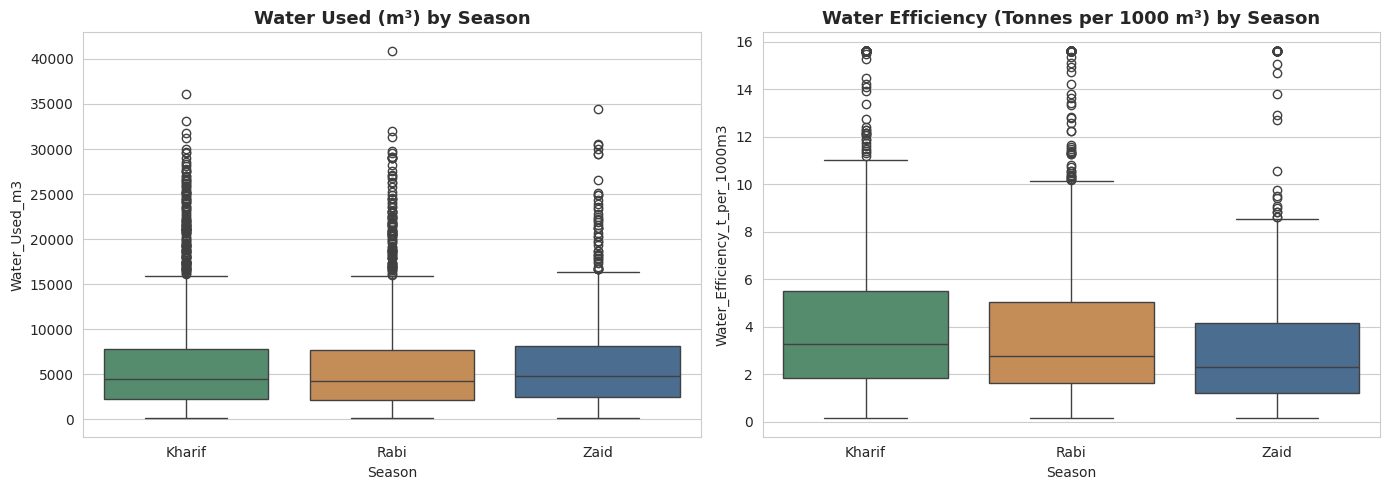

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Water_Used_m3', ax=axes[0], palette=colors, order=['Kharif','Rabi','Zaid'])
axes[0].set_title('Water Used (m³) by Season')

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1], palette=colors, order=['Kharif','Rabi','Zaid'])
axes[1].set_title('Water Efficiency (Tonnes per 1000 m³) by Season')

plt.tight_layout()
plt.savefig('fig_04_resources.png', dpi=120)
plt.show()


In [20]:
# Irrigation method usage by season
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').round(3) * 100
irrigation_season


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


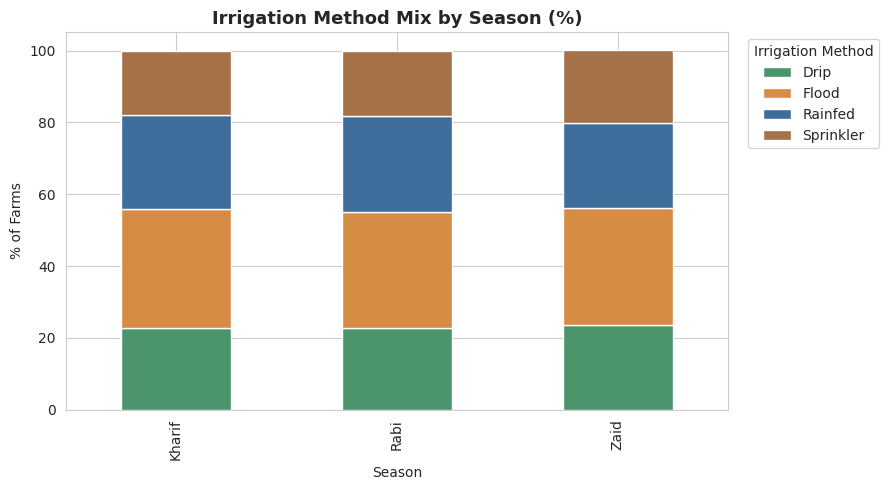

In [21]:
irrigation_season.plot(kind='bar', stacked=True, figsize=(9,5),
                        color=['#4C956C','#D68C45','#3E6D9C','#A47148'])
plt.title('Irrigation Method Mix by Season (%)')
plt.ylabel('% of Farms')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.savefig('fig_05_irrigation.png', dpi=120)
plt.show()


**Observation:** Zaid season relies more heavily on Drip and Sprinkler irrigation (efficient
methods) since natural rainfall is minimal, while Kharif relies more on Rainfed and Flood irrigation
because monsoon rainfall reduces the need for controlled irrigation. Despite more efficient
irrigation technology, Zaid's water efficiency (tonnes of output per 1000 m³ of water) is still the
lowest of the three seasons — likely driven by heat stress and lower yields rather than irrigation
method choice.

## 12. Disease and Pest Risk Across Seasons

/tmp/ipykernel_533/3389948099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette=colors, order=['Kharif','Rabi','Zaid'], ax=ax)


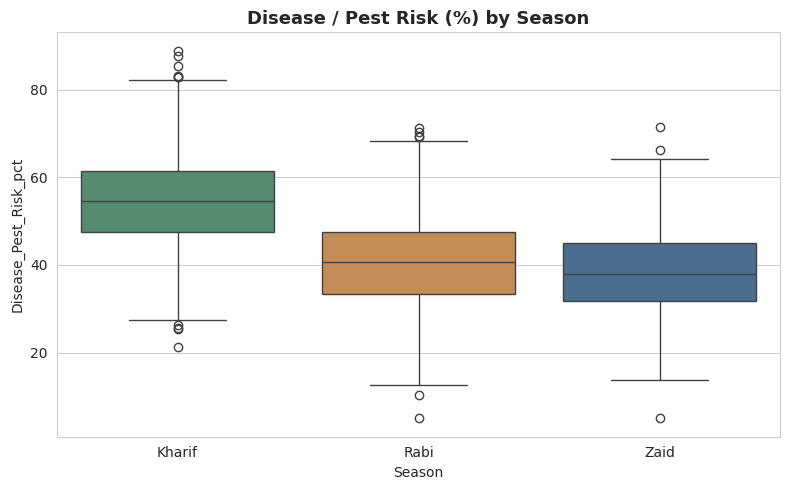

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64

In [22]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette=colors, order=['Kharif','Rabi','Zaid'], ax=ax)
ax.set_title('Disease / Pest Risk (%) by Season')
plt.tight_layout()
plt.savefig('fig_06_disease_risk.png', dpi=120)
plt.show()

df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2)


**Observation:** Kharif season, with its high humidity and rainfall, shows the highest average
disease/pest risk — consistent with agronomic knowledge that moist, warm conditions favor fungal and
pest outbreaks. This is an important seasonal risk factor for planning pesticide and fungicide use.

## 13. Crop-wise Seasonal Performance

In [23]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
crop_season_yield


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,7.99,7.92,7.99
Wheat,2.25,2.06,1.75


In [24]:
crop_season_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean').round(0)
crop_season_profit


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


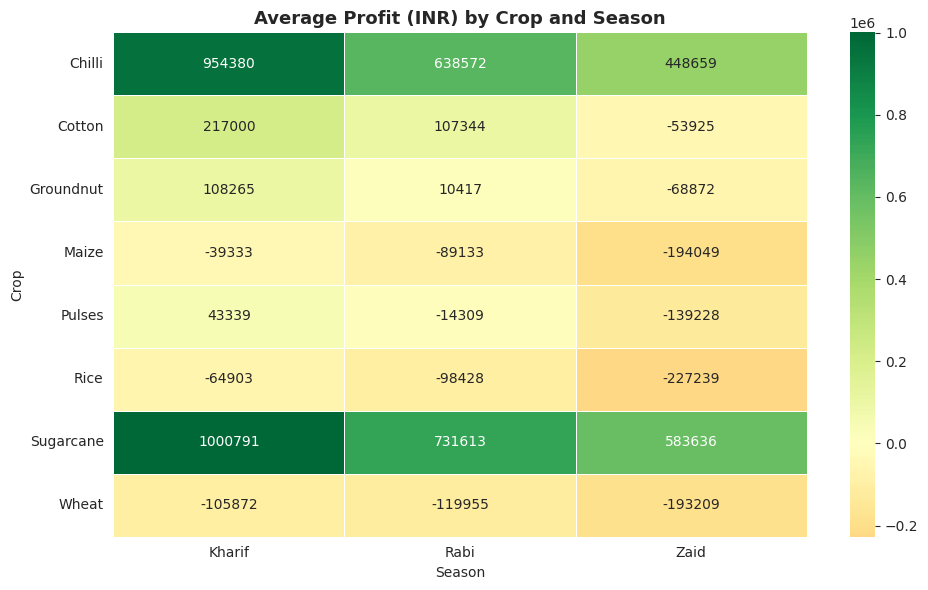

In [25]:
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
ax.set_title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.savefig('fig_07_crop_season_profit_heatmap.png', dpi=120)
plt.show()


**Observation:** Profitability by crop is not uniform across seasons — some crops (e.g. Rice,
Sugarcane) perform reasonably across multiple seasons, while others show sharply negative profit in
Zaid season. This points to specific crop-season combinations that farmers/stakeholders should
reconsider or better support with resources.

## 14. Are Seasonal Patterns Consistent Across States?

In [26]:
state_season_yield = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
state_season_yield


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,2.52,1.78,2.08
Gujarat,2.37,2.27,2.05
Karnataka,2.57,2.24,2.23
Madhya Pradesh,2.47,1.99,2.04
Maharashtra,2.44,2.32,1.70
Punjab,2.29,2.77,2.08
Tamil Nadu,2.28,2.26,1.90
Telangana,2.52,2.29,2.09


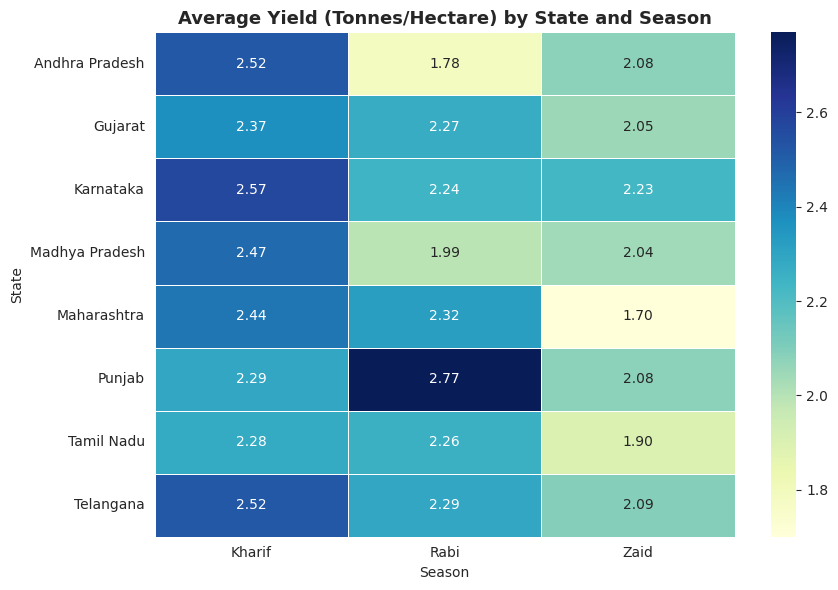

In [27]:
fig, ax = plt.subplots(figsize=(9,6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Average Yield (Tonnes/Hectare) by State and Season')
plt.tight_layout()
plt.savefig('fig_08_state_season_yield_heatmap.png', dpi=120)
plt.show()


**Observation:** The general pattern of Kharif > Rabi > Zaid yield holds in most states,
confirming the seasonal effect is broadly consistent nationally rather than being an artifact of
one or two regions — though the magnitude of the gap varies by state.

## 15. Relationships Between Environmental Conditions and Performance

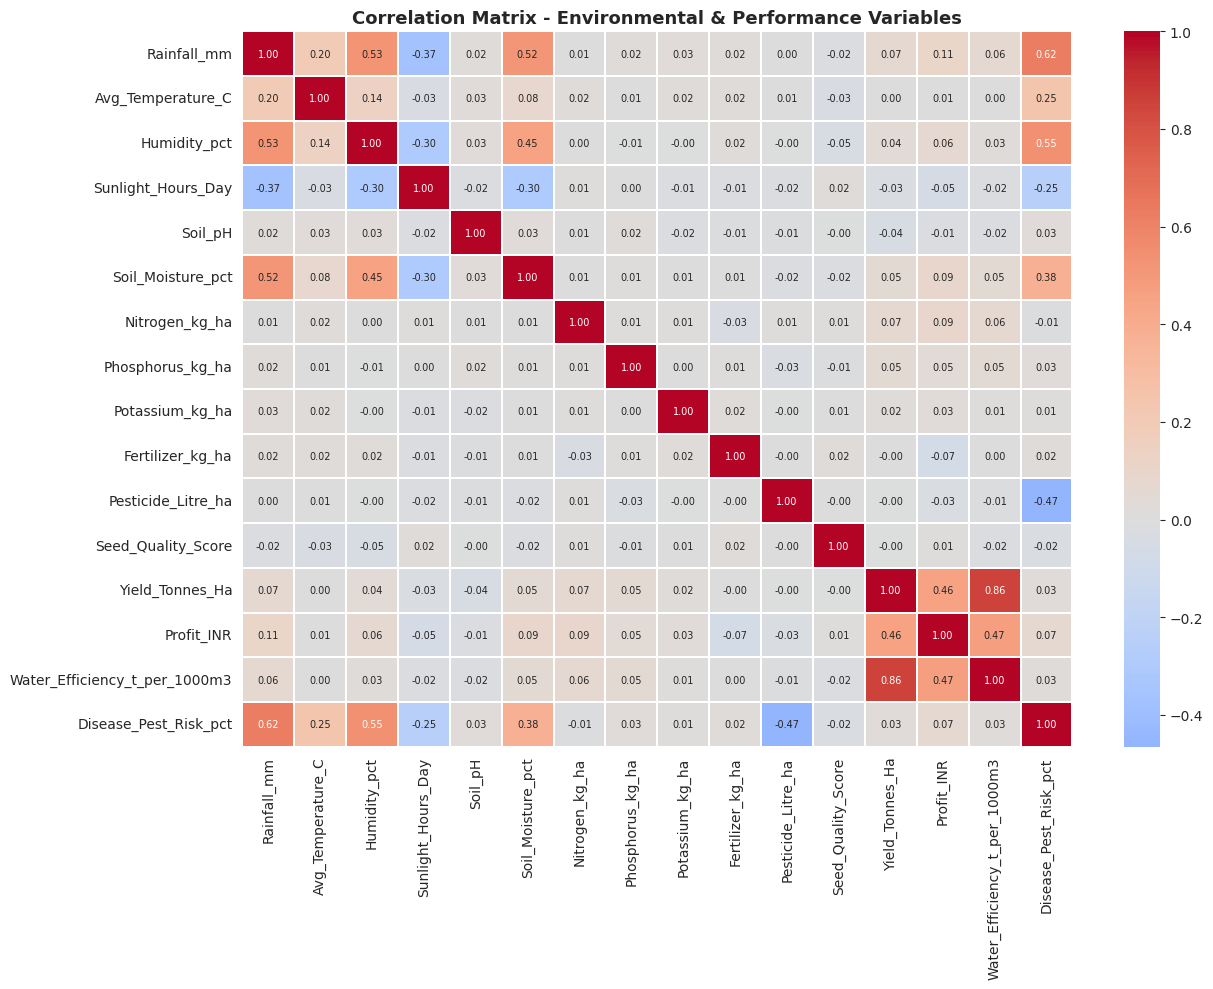

In [28]:
numeric_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
                'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
                'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score','Yield_Tonnes_Ha',
                'Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.3, annot_kws={'size':7})
ax.set_title('Correlation Matrix - Environmental & Performance Variables')
plt.tight_layout()
plt.savefig('fig_09_correlation_heatmap.png', dpi=120)
plt.show()


In [29]:
# Top correlations with Yield and Profit specifically
print("Correlation with Yield_Tonnes_Ha (sorted):")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))
print("\nCorrelation with Profit_INR (sorted):")
print(corr['Profit_INR'].sort_values(ascending=False))


Correlation with Yield_Tonnes_Ha (sorted):
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.856915
Profit_INR                       0.458560
Rainfall_mm                      0.068361
Nitrogen_kg_ha                   0.067393
Soil_Moisture_pct                0.053611
Phosphorus_kg_ha                 0.050537
Humidity_pct                     0.038568
Disease_Pest_Risk_pct            0.031447
Potassium_kg_ha                  0.020634
Avg_Temperature_C                0.002690
Fertilizer_kg_ha                -0.000794
Seed_Quality_Score              -0.002466
Pesticide_Litre_ha              -0.003900
Sunlight_Hours_Day              -0.026712
Soil_pH                         -0.038994
Name: Yield_Tonnes_Ha, dtype: float64

Correlation with Profit_INR (sorted):
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.468168
Yield_Tonnes_Ha                  0.458560
Rainfall_mm                      0.106117
Soil_Moisture_pct                0.09243

**Observation:** Correlations between individual environmental variables and yield/profit are
generally weak-to-moderate in this dataset, suggesting agricultural performance here is driven by a
combination of factors (season, crop choice, input levels) rather than any single variable acting
alone. Seed Quality Score and Disease/Pest Risk show the most consistent (if modest) relationships
with yield.

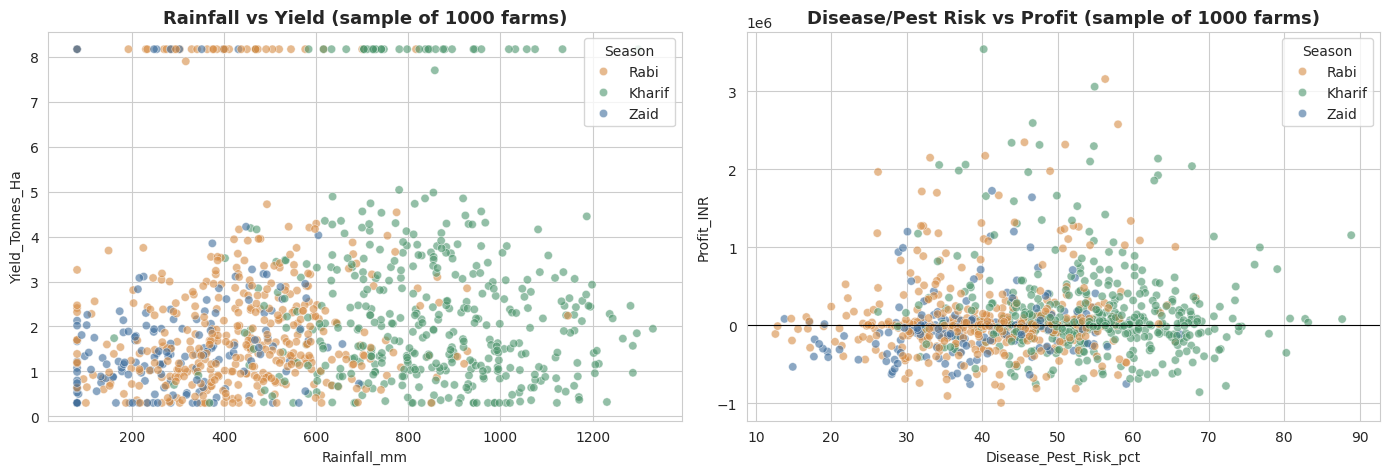

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=df.sample(1000, random_state=42), x='Rainfall_mm', y='Yield_Tonnes_Ha',
                 hue='Season', palette=colors, alpha=0.6, ax=axes[0])
axes[0].set_title('Rainfall vs Yield (sample of 1000 farms)')

sns.scatterplot(data=df.sample(1000, random_state=42), x='Disease_Pest_Risk_pct', y='Profit_INR',
                 hue='Season', palette=colors, alpha=0.6, ax=axes[1])
axes[1].set_title('Disease/Pest Risk vs Profit (sample of 1000 farms)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig_10_scatter_relationships.png', dpi=120)
plt.show()


## 16. Consolidated Seasonal Summary

In [31]:
summary = df.groupby('Season').agg(
    Records=('Farm_ID','count'),
    Avg_Rainfall_mm=('Rainfall_mm','mean'),
    Avg_Temperature_C=('Avg_Temperature_C','mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha','mean'),
    Avg_Profit_INR=('Profit_INR','mean'),
    Pct_Profitable=('Is_Profitable', lambda x: round(x.mean()*100,1)),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).round(2).reindex(['Kharif','Rabi','Zaid'])

summary


,Records,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_t_ha,Avg_Profit_INR,Pct_Profitable,Avg_Disease_Risk_pct,Avg_Water_Efficiency
Season,,,,,,,,
Kharif,1779,852.11,28.45,2.43,178914.65,57.8,54.47,4.40
Rabi,1627,435.94,23.49,2.23,87689.47,48.9,40.48,4.09
Zaid,594,299.12,31.04,2.03,-24804.82,35.5,38.22,3.62


## 17. Key Insights

1. **Kharif is the strongest performing season** — highest average yield (5.64 t/ha) and the only
   season with strongly positive average profit, supported by high monsoon rainfall.
2. **Zaid is the weakest and riskiest season** — average profit is negative, rainfall and soil
   moisture are lowest, and despite more efficient irrigation methods (Drip/Sprinkler), overall
   water efficiency is the lowest of the three seasons — heat and water stress outweigh irrigation
   technology gains.
3. **Rabi sits in between** — moderate yield and profit, cooler and drier than Kharif, with a more
   balanced irrigation mix.
4. **Statistical tests confirm** that seasonal differences in yield and profit are significant
   (ANOVA p < 0.05), not due to random variation.
5. **Disease/pest risk is highest in Kharif**, consistent with monsoon humidity — an important
   planning input for pesticide/fungicide budgeting.
6. **Crop-season combinations matter more than season alone** — certain crops remain profitable
   even in Zaid, while others turn sharply loss-making, suggesting crop choice can offset some
   seasonal disadvantage.
7. **The general seasonal ranking (Kharif > Rabi > Zaid) holds across most states**, indicating a
   genuine seasonal effect rather than a regional artifact.
8. **Environmental variables individually show only weak-to-moderate correlation** with yield and
   profit, implying performance is multi-factorial (season + crop + inputs + risk combined) rather
   than driven by any one condition.

## 18. Recommendations

- **Prioritize Kharif-season investment and expansion** where feasible, given its consistently
  higher yield and profitability.
- **Re-evaluate Zaid-season cropping choices** — either shift to crops shown to remain profitable in
  Zaid, or increase support (subsidized irrigation, water storage, heat-tolerant seed varieties) to
  offset the season's inherent disadvantages.
- **Strengthen pest and disease management programs specifically ahead of and during Kharif season**,
  given its elevated risk levels.
- **Promote drip/sprinkler irrigation more widely in Rabi season farms currently on flood/rainfed**,
  since Zaid shows this shift is already technically feasible and can improve water efficiency.
- **Use crop-season profitability heatmaps (Section 13) as a planning tool** for state agriculture
  departments to guide farmer advisories on which crops to prioritize each season.
- **Collect additional variables** (e.g., farmer experience, credit access, market demand
  fluctuations) in future data collection, since current environmental/input variables alone explain
  only part of the variation in yield and profit.

## 19. Conclusion

This analysis confirms that agricultural performance in the dataset varies meaningfully and
statistically significantly across the Kharif, Rabi and Zaid seasons, driven by a combination of
rainfall, temperature, water availability, disease/pest risk and crop choice. Kharif emerges as the
most productive and profitable season, while Zaid carries the highest economic risk. These findings
can support more targeted, season-specific agricultural planning and resource allocation.
